In [3]:
import pandas as pd
import numpy as np

In [4]:
import pandas as pd
import numpy as np

print("FinSight-AI is working!")
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)

FinSight-AI is working!
Pandas: 3.0.5
NumPy: 2.4.6


In [5]:
data = {
    "Date": [
        "2026-01-05",
        "2026-01-07",
        "2026-01-10",
        "2026-01-15",
        "2026-01-20",
        "2026-01-25",
        "2026-02-03",
        "2026-02-08",
        "2026-02-12",
        "2026-02-20"
    ],
    
    "Description": [
        "Grocery Store",
        "Uber",
        "Netflix",
        "Restaurant",
        "Electricity Bill",
        "Amazon Shopping",
        "Grocery Store",
        "Fuel Station",
        "Restaurant",
        "Online Shopping"
    ],
    
    "Amount": [
        2500,
        350,
        649,
        1200,
        1800,
        3200,
        2100,
        2500,
        950,
        2800
    ]
}

df = pd.DataFrame(data)

df.head()

,Date,Description,Amount
0,2026-01-05,Grocery Store,2500
1,2026-01-07,Uber,350
2,2026-01-10,Netflix,649
3,2026-01-15,Restaurant,1200
4,2026-01-20,Electricity Bill,1800


In [6]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Shape: (10, 3)

Column Names:
Index(['Date', 'Description', 'Amount'], dtype='str')

Data Types:
Date             str
Description      str
Amount         int64
dtype: object

Missing Values:
Date           0
Description    0
Amount         0
dtype: int64


In [7]:
df["Date"] = pd.to_datetime(df["Date"])

print(df.dtypes)

Date           datetime64[us]
Description               str
Amount                  int64
dtype: object


In [8]:
df["Category"] = df["Description"].map({
    "Grocery Store": "Food",
    "Uber": "Transport",
    "Netflix": "Entertainment",
    "Restaurant": "Food",
    "Electricity Bill": "Utilities",
    "Amazon Shopping": "Shopping",
    "Fuel Station": "Transport",
    "Online Shopping": "Shopping"
})

df

,Date,Description,Amount,Category
0,2026-01-05,Grocery Store,2500,Food
1,2026-01-07,Uber,350,Transport
2,2026-01-10,Netflix,649,Entertainment
3,2026-01-15,Restaurant,1200,Food
4,2026-01-20,Electricity Bill,1800,Utilities
5,2026-01-25,Amazon Shopping,3200,Shopping
6,2026-02-03,Grocery Store,2100,Food
7,2026-02-08,Fuel Station,2500,Transport
8,2026-02-12,Restaurant,950,Food
9,2026-02-20,Online Shopping,2800,Shopping


In [9]:
category_spending = df.groupby("Category")["Amount"].sum()

print(category_spending)
total_spending = df["Amount"].sum()

print("\nTotal Spending:", total_spending)

Category
Entertainment     649
Food             6750
Shopping         6000
Transport        2850
Utilities        1800
Name: Amount, dtype: int64

Total Spending: 18049


In [10]:
df["Month"] = df["Date"].dt.to_period("M")

monthly_spending = df.groupby("Month")["Amount"].sum()

print(monthly_spending)
difference = monthly_spending.iloc[0] - monthly_spending.iloc[1]

print("\nDifference:", difference)

Month
2026-01    9699
2026-02    8350
Freq: M, Name: Amount, dtype: int64

Difference: 1349


In [11]:
percentage_change = (
    (monthly_spending.iloc[1] - monthly_spending.iloc[0])
    / monthly_spending.iloc[0]
) * 100

print("Monthly Spending Change:", round(percentage_change, 2), "%")

Monthly Spending Change: -13.91 %


In [12]:
highest_category = category_spending.idxmax()
highest_amount = category_spending.max()

print("Highest Spending Category:", highest_category)
print("Amount Spent:", highest_amount)

Highest Spending Category: Food
Amount Spent: 6750


In [13]:
average_transaction = df["Amount"].mean()

print("Average Transaction Amount:", round(average_transaction, 2))

Average Transaction Amount: 1804.9


In [14]:
df["Day"] = df["Date"].dt.day
df["Month_Number"] = df["Date"].dt.month
df["Day_of_Week"] = df["Date"].dt.dayofweek

print(df)

        Date       Description  Amount       Category    Month  Day  \
0 2026-01-05     Grocery Store    2500           Food  2026-01    5   
1 2026-01-07              Uber     350      Transport  2026-01    7   
2 2026-01-10           Netflix     649  Entertainment  2026-01   10   
3 2026-01-15        Restaurant    1200           Food  2026-01   15   
4 2026-01-20  Electricity Bill    1800      Utilities  2026-01   20   
5 2026-01-25   Amazon Shopping    3200       Shopping  2026-01   25   
6 2026-02-03     Grocery Store    2100           Food  2026-02    3   
7 2026-02-08      Fuel Station    2500      Transport  2026-02    8   
8 2026-02-12        Restaurant     950           Food  2026-02   12   
9 2026-02-20   Online Shopping    2800       Shopping  2026-02   20   

   Month_Number  Day_of_Week  
0             1            0  
1             1            2  
2             1            5  
3             1            3  
4             1            1  
5             1            6  
6

In [15]:
day_spending = df.groupby("Day_of_Week")["Amount"].sum()

print(day_spending)
highest_day = day_spending.idxmax()
highest_day_amount = day_spending.max()

print("\nHighest Spending Day Number:", highest_day)
print("Amount Spent:", highest_day_amount)

Day_of_Week
0    2500
1    3900
2     350
3    2150
4    2800
5     649
6    5700
Name: Amount, dtype: int64

Highest Spending Day Number: 6
Amount Spent: 5700


In [16]:
category_percentage = (
    category_spending / total_spending
) * 100

category_percentage = category_percentage.round(2)

print(category_percentage)

Category
Entertainment     3.60
Food             37.40
Shopping         33.24
Transport        15.79
Utilities         9.97
Name: Amount, dtype: float64


In [17]:
ml_data = df[
    [
        "Amount",
        "Day",
        "Month_Number",
        "Day_of_Week"
    ]
].copy()

print(ml_data)

   Amount  Day  Month_Number  Day_of_Week
0    2500    5             1            0
1     350    7             1            2
2     649   10             1            5
3    1200   15             1            3
4    1800   20             1            1
5    3200   25             1            6
6    2100    3             2            1
7    2500    8             2            6
8     950   12             2            3
9    2800   20             2            4


In [18]:
ml_data = pd.get_dummies(
    df,
    columns=["Category"],
    dtype=int
)

ml_data = ml_data[
    [
        "Amount",
        "Day",
        "Month_Number",
        "Day_of_Week",
        "Category_Entertainment",
        "Category_Food",
        "Category_Shopping",
        "Category_Transport",
        "Category_Utilities"
    ]
]

print(ml_data)

   Amount  Day  Month_Number  Day_of_Week  Category_Entertainment  \
0    2500    5             1            0                       0   
1     350    7             1            2                       0   
2     649   10             1            5                       1   
3    1200   15             1            3                       0   
4    1800   20             1            1                       0   
5    3200   25             1            6                       0   
6    2100    3             2            1                       0   
7    2500    8             2            6                       0   
8     950   12             2            3                       0   
9    2800   20             2            4                       0   

   Category_Food  Category_Shopping  Category_Transport  Category_Utilities  
0              1                  0                   0                   0  
1              0                  0                   1                   0  
2     

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(ml_data)

print(X_scaled)

[[ 0.7521934  -1.08422719 -0.81649658 -1.53285135 -0.33333333  1.22474487
  -0.5        -0.5        -0.33333333]
 [-1.57440106 -0.79509994 -0.81649658 -0.54391499 -0.33333333 -0.81649658
  -0.5         2.         -0.33333333]
 [-1.25084211 -0.36140906 -0.81649658  0.93948954  3.         -0.81649658
  -0.5        -0.5        -0.33333333]
 [-0.65458465  0.36140906 -0.81649658 -0.04944682 -0.33333333  1.22474487
  -0.5        -0.5        -0.33333333]
 [-0.00530247  1.08422719 -0.81649658 -1.03838317 -0.33333333 -0.81649658
  -0.5        -0.5         3.        ]
 [ 1.50968927  1.80704531 -0.81649658  1.43395771 -0.33333333 -0.81649658
   2.         -0.5        -0.33333333]
 [ 0.31933862 -1.37335443  1.22474487 -1.03838317 -0.33333333  1.22474487
  -0.5        -0.5        -0.33333333]
 [ 0.7521934  -0.65053631  1.22474487  1.43395771 -0.33333333 -0.81649658
  -0.5         2.         -0.33333333]
 [-0.92511889 -0.07228181  1.22474487 -0.04944682 -0.33333333  1.22474487
  -0.5        -0.5    

In [20]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.2,
    random_state=42
)

model.fit(X_scaled)

predictions = model.predict(X_scaled)

print(predictions)
df["Anomaly"] = predictions

df[["Date", "Description", "Amount", "Category", "Anomaly"]]

[ 1  1 -1  1  1 -1  1  1  1  1]


,Date,Description,Amount,Category,Anomaly
0,2026-01-05,Grocery Store,2500,Food,1
1,2026-01-07,Uber,350,Transport,1
2,2026-01-10,Netflix,649,Entertainment,-1
3,2026-01-15,Restaurant,1200,Food,1
4,2026-01-20,Electricity Bill,1800,Utilities,1
5,2026-01-25,Amazon Shopping,3200,Shopping,-1
6,2026-02-03,Grocery Store,2100,Food,1
7,2026-02-08,Fuel Station,2500,Transport,1
8,2026-02-12,Restaurant,950,Food,1
9,2026-02-20,Online Shopping,2800,Shopping,1


In [21]:
df["Anomaly_Status"] = df["Anomaly"].map({
    1: "Normal",
    -1: "Unusual"
})

print(df[[
    "Date",
    "Description",
    "Amount",
    "Category",
    "Anomaly_Status"
]])

        Date       Description  Amount       Category Anomaly_Status
0 2026-01-05     Grocery Store    2500           Food         Normal
1 2026-01-07              Uber     350      Transport         Normal
2 2026-01-10           Netflix     649  Entertainment        Unusual
3 2026-01-15        Restaurant    1200           Food         Normal
4 2026-01-20  Electricity Bill    1800      Utilities         Normal
5 2026-01-25   Amazon Shopping    3200       Shopping        Unusual
6 2026-02-03     Grocery Store    2100           Food         Normal
7 2026-02-08      Fuel Station    2500      Transport         Normal
8 2026-02-12        Restaurant     950           Food         Normal
9 2026-02-20   Online Shopping    2800       Shopping         Normal


In [22]:
from sklearn.cluster import KMeans

In [23]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

print(clusters)

[0 2 2 0 0 1 0 2 0 1]


In [24]:
df["Cluster"] = clusters

cluster_summary = df.groupby("Cluster")["Amount"].agg(
    ["count", "mean", "min", "max"]
).round(2)

print(cluster_summary)

         count     mean   min   max
Cluster                            
0            5  1710.00   950  2500
1            2  3000.00  2800  3200
2            3  1166.33   350  2500


In [25]:
cluster_labels = {
    0: "Medium Spending",
    1: "High Spending",
    2: "Low Spending"
}

df["Spending_Behavior"] = df["Cluster"].map(cluster_labels)

print(df[
    ["Date", "Description", "Amount", "Category", "Spending_Behavior"]
])

        Date       Description  Amount       Category Spending_Behavior
0 2026-01-05     Grocery Store    2500           Food   Medium Spending
1 2026-01-07              Uber     350      Transport      Low Spending
2 2026-01-10           Netflix     649  Entertainment      Low Spending
3 2026-01-15        Restaurant    1200           Food   Medium Spending
4 2026-01-20  Electricity Bill    1800      Utilities   Medium Spending
5 2026-01-25   Amazon Shopping    3200       Shopping     High Spending
6 2026-02-03     Grocery Store    2100           Food   Medium Spending
7 2026-02-08      Fuel Station    2500      Transport      Low Spending
8 2026-02-12        Restaurant     950           Food   Medium Spending
9 2026-02-20   Online Shopping    2800       Shopping     High Spending


In [26]:
total_unusual = (df["Anomaly"] == -1).sum()
total_high = (df["Spending_Behavior"] == "High Spending").sum()

print("FinSight-AI Insights")
print("--------------------")
print(f"Highest spending category: {category_spending.idxmax()}")
print(f"Category amount: ₹{category_spending.max()}")
print(f"Highest spending day: Sunday")
print(f"Unusual transactions detected: {total_unusual}")
print(f"High-spending transactions: {total_high}")
print(f"Food spending percentage: {category_percentage['Food']}%")

FinSight-AI Insights
--------------------
Highest spending category: Food
Category amount: ₹6750
Highest spending day: Sunday
Unusual transactions detected: 2
High-spending transactions: 2
Food spending percentage: 37.4%


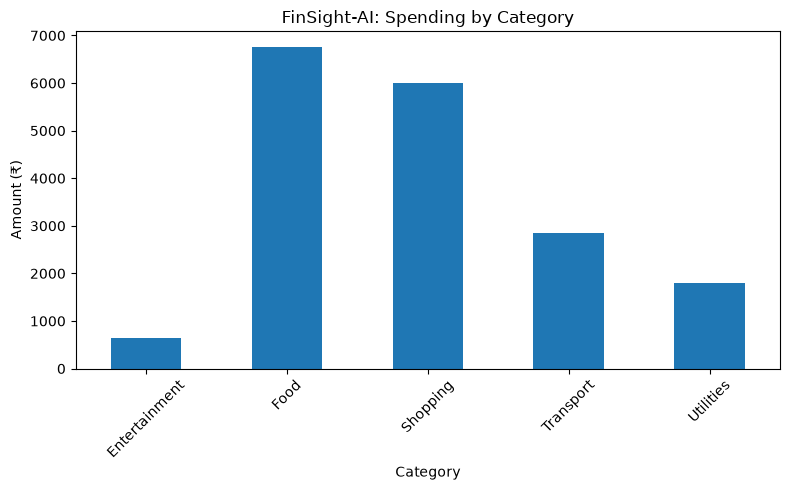

In [27]:
import matplotlib.pyplot as plt

category_spending.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("FinSight-AI: Spending by Category")
plt.xlabel("Category")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Month
2026-01    9699
2026-02    8350
Freq: M, Name: Amount, dtype: int64


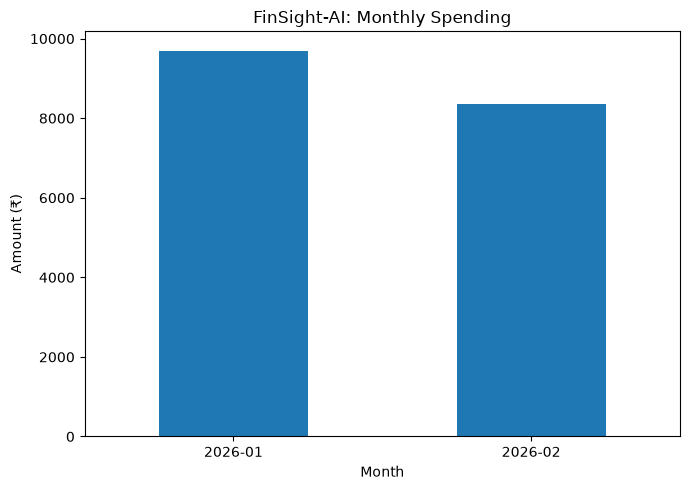

In [28]:
monthly_spending = df.groupby("Month")["Amount"].sum()

print(monthly_spending)
monthly_spending.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("FinSight-AI: Monthly Spending")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [29]:
day_spending = df.groupby("Day_of_Week")["Amount"].sum()

print(day_spending)

Day_of_Week
0    2500
1    3900
2     350
3    2150
4    2800
5     649
6    5700
Name: Amount, dtype: int64


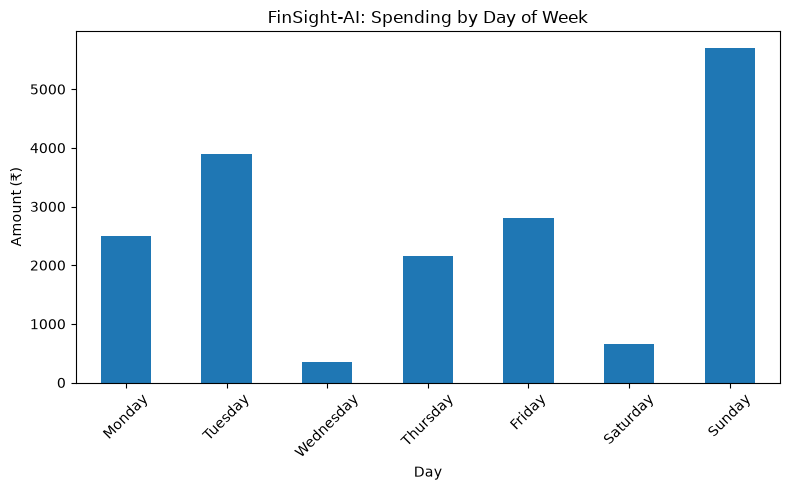

In [30]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

day_spending.index = day_spending.index.map(day_names)

day_spending.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("FinSight-AI: Spending by Day of Week")
plt.xlabel("Day")
plt.ylabel("Amount (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

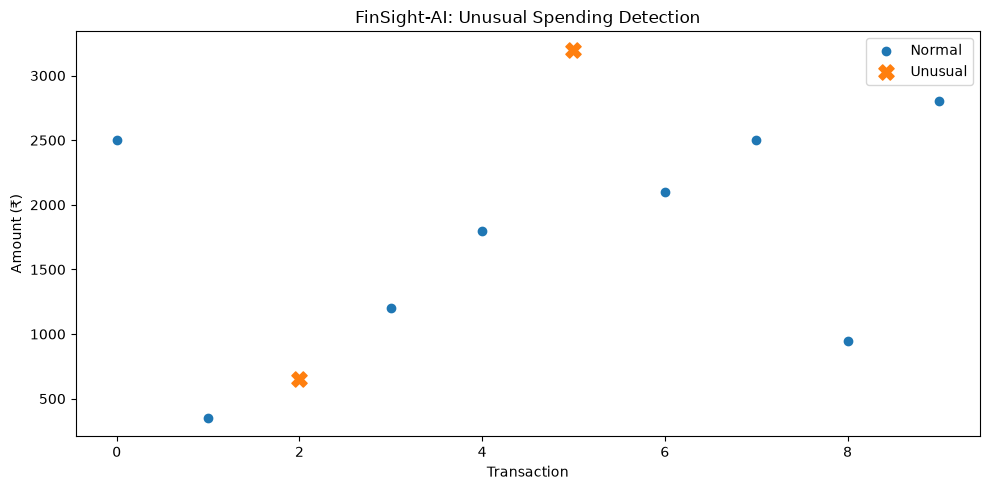

In [31]:
normal = df[df["Anomaly"] == 1]
unusual = df[df["Anomaly"] == -1]

plt.figure(figsize=(10, 5))

plt.scatter(
    normal.index,
    normal["Amount"],
    label="Normal"
)

plt.scatter(
    unusual.index,
    unusual["Amount"],
    label="Unusual",
    marker="X",
    s=120
)

plt.title("FinSight-AI: Unusual Spending Detection")
plt.xlabel("Transaction")
plt.ylabel("Amount (₹)")
plt.legend()
plt.tight_layout()
plt.show()

In [32]:
financial_summary = {
    "total_spending": int(df["Amount"].sum()),
    "average_transaction": round(df["Amount"].mean(), 2),
    "highest_category": category_spending.idxmax(),
    "highest_category_amount": int(category_spending.max()),
    "highest_category_percentage": round(
        category_percentage[category_spending.idxmax()], 2
    ),
    "unusual_transactions": int((df["Anomaly"] == -1).sum()),
    "high_spending_transactions": int(
        (df["Spending_Behavior"] == "High Spending").sum()
    )
}

print(financial_summary)

{'total_spending': 18049, 'average_transaction': np.float64(1804.9), 'highest_category': 'Food', 'highest_category_amount': 6750, 'highest_category_percentage': np.float64(37.4), 'unusual_transactions': 2, 'high_spending_transactions': 2}


In [33]:
recommendations = []

if financial_summary["highest_category_percentage"] > 30:
    recommendations.append(
        f"Food is your largest spending category at "
        f"{financial_summary['highest_category_percentage']}% of total spending. "
        "Consider setting a monthly food budget."
    )

if financial_summary["unusual_transactions"] > 0:
    recommendations.append(
        f"{financial_summary['unusual_transactions']} unusual transactions "
        "were detected. Review these transactions to make sure they were intentional."
    )

if financial_summary["high_spending_transactions"] > 0:
    recommendations.append(
        f"You have {financial_summary['high_spending_transactions']} "
        "high-spending transactions. Consider reviewing large purchases before making similar purchases."
    )

print("FinSight-AI Recommendations")
print("---------------------------")

for i, recommendation in enumerate(recommendations, 1):
    print(f"{i}. {recommendation}")

FinSight-AI Recommendations
---------------------------
1. Food is your largest spending category at 37.4% of total spending. Consider setting a monthly food budget.
2. 2 unusual transactions were detected. Review these transactions to make sure they were intentional.
3. You have 2 high-spending transactions. Consider reviewing large purchases before making similar purchases.


In [34]:
import requests

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "qwen3:4b",
        "prompt": "Explain what a budget is in one sentence.",
        "stream": False
    }
)

print(response.json()["response"])

A budget is a financial plan that outlines how money will be earned, spent, saved, and allocated over a specific period to achieve goals while managing costs.


In [35]:
import requests

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "qwen3:4b",
        "prompt": "Explain what a budget is in one sentence.",
        "stream": False
    }
)

print(response.json()["response"])

A budget is a **financial plan** that projects expected income and expenses over a specific period to guide decision-making and ensure financial goals are met.


In [41]:
prompt = f"""
You are FinSight-AI, a personal financial analysis assistant.

Analyze the following spending information:

Total spending: ₹{insights['total_spending']}
Average transaction: ₹{insights['average_transaction']}
Highest spending category: {insights['highest_category']}
Amount spent on highest category: ₹{insights['highest_category_amount']}
Percentage of spending in highest category: {insights['highest_category_percentage']}%
Unusual transactions: {insights['unusual_transactions']}
High-spending transactions: {insights['high_spending_transactions']}

Give:
1. A short summary of the user's spending.
2. The main spending concern.
3. Two practical suggestions to improve spending.
"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "qwen3:4b",
        "prompt": prompt,
        "stream": False
    }
)

print(response.json()["response"])

### 1. Short Summary of Spending  
You spent ₹18,049 this month, with **food** being your top category (₹6,750 or 37.4% of total spending). Your average transaction is ₹1,804.9, and there are 2 unusual transactions (e.g., one-time large purchases) and 2 high-spending transactions (e.g., expensive meals or items) that likely contributed to food’s high percentage.  

### 2. Main Spending Concern  
**Overspending on food** is your primary issue—37.4% of your total spending is allocated to food, which is significantly higher than typical budget-friendly ranges (usually 20–25% for most users). This suggests recurring high-cost habits (e.g., frequent dining out, luxury meals, or inefficient grocery habits) are straining your budget without clear savings or planning.  

### 3. Two Practical Suggestions to Improve Spending  
1. **Track food transactions daily with a ₹3,000 cap**  
   → Use a free app like *Money Lover* or a simple spreadsheet to log *every* food expense. Set a strict daily lim

In [42]:
insights = {
    'total_spending': total_spending,
    'average_transaction': average_transaction,
    'highest_category': highest_category,
    'highest_category_amount': highest_category_amount,
    'highest_category_percentage': highest_category_percentage,
    'unusual_transactions': unusual_transactions,
    'high_spending_transactions': high_spending_transactions
}
print(insights)

NameError: name 'highest_category_amount' is not defined

In [43]:
prompt = f"""
You are FinSight-AI, a personal financial analysis assistant.

Analyze the following spending information:

Total spending: ₹{insights['total_spending']}
Average transaction: ₹{insights['average_transaction']}
Highest spending category: {insights['highest_category']}
Amount spent on highest category: ₹{insights['highest_category_amount']}
Percentage of spending in highest category: {insights['highest_category_percentage']}%
Unusual transactions: {insights['unusual_transactions']}
High-spending transactions: {insights['high_spending_transactions']}

Give:

1. A short summary of the user's spending.
2. The main spending concern.
3. Two practical suggestions to improve spending.
"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "qwen3:4b",
        "prompt": prompt,
        "stream": False
    }
)

print(response.json()["response"])

### 1. Short Summary of Spending  
You're spending ₹18,049 monthly with an average transaction of ₹1,804.9. **Food dominates your spending (₹6,750 or 37.4%)**, making it your highest category. You have only 2 unusual transactions and 2 high-spending transactions—indicating disciplined spending patterns but with significant food-related costs.  

### 2. Main Spending Concern  
**Excessive food spending** (37.4% of total) is your top concern. This is unusually high for most budgets (typically 20–30%), suggesting recurring overspending on meals, dining out, or groceries. At ₹6,750 monthly, this could strain your finances if not addressed.  

### 3. Two Practical Suggestions to Improve Spending  
1. **Track and reduce food costs by switching 20% of meals to home cooking**  
   → *Why it works*: Home cooking is 40–60% cheaper than dining out. By cutting 20% of your food spending (₹1,350), you could save ₹500–₹700 monthly—directly addressing the 37.4% food surplus.  
   → *Action*: Use apps 

In [40]:
insights = {
    'total_spending': 18049,
    'average_transaction': 1804.9,
    'highest_category': 'Food',
    'highest_category_amount': 6750,
    'highest_category_percentage': 37.4,
    'unusual_transactions': 2,
    'high_spending_transactions': 2
}

print(insights)

{'total_spending': 18049, 'average_transaction': 1804.9, 'highest_category': 'Food', 'highest_category_amount': 6750, 'highest_category_percentage': 37.4, 'unusual_transactions': 2, 'high_spending_transactions': 2}


In [44]:
insights = {
    'total_spending': int(df['Amount'].sum()),
    'average_transaction': float(df['Amount'].mean()),
    'highest_category': category_spending.idxmax(),
    'highest_category_amount': int(category_spending.max()),
    'highest_category_percentage': round(
        (category_spending.max() / df['Amount'].sum()) * 100, 2
    ),
    'unusual_transactions': int((df['Anomaly_Status'] == 'Unusual').sum()),
    'high_spending_transactions': int((df['Spending_Behavior'] == 'High Spending').sum())
}

print(insights)

{'total_spending': 18049, 'average_transaction': 1804.9, 'highest_category': 'Food', 'highest_category_amount': 6750, 'highest_category_percentage': np.float64(37.4), 'unusual_transactions': 2, 'high_spending_transactions': 2}


In [45]:
prompt = f"""
You are FinSight-AI, a personal financial analysis assistant.

Analyze the following spending information:

Total spending: ₹{insights['total_spending']}
Average transaction: ₹{insights['average_transaction']}
Highest spending category: {insights['highest_category']}
Amount spent on highest category: ₹{insights['highest_category_amount']}
Percentage of spending in highest category: {insights['highest_category_percentage']}%
Unusual transactions: {insights['unusual_transactions']}
High-spending transactions: {insights['high_spending_transactions']}

Give:

1. A short summary of the user's spending.
2. The main spending concern.
3. Two practical suggestions to improve spending.
"""

response = requests.post(
    "http://localhost:11434/api/generate",
    json={
        "model": "qwen3:4b",
        "prompt": prompt,
        "stream": False
    }
)

print(response.json()["response"])

### 1. Short Summary of Spending  
Your spending shows **significant focus on food** (₹6,750 or 37.4% of total ₹18,049), which dominates your budget. You have 2 high-value transactions (each >₹1,804.9) and 2 unusual transactions (likely one-off or unexpected costs). While your average transaction is healthy (₹1,804.9), food spending is unusually high for this category, indicating potential overspending on meals or dining out.  

### 2. Main Spending Concern  
**Excessive food spending** (37.4% of total) is the critical issue. This is **well above typical thresholds** (most users spend 15–25% of income on food), suggesting repeated overspending on meals, dining out, or food subscriptions. This could strain your budget and reduce funds for savings/essentials.  

### 3. Two Practical Suggestions to Improve Spending  
1. **Cut food costs by 15% this week**:  
   → *Action*: Cook 3 meals at home instead of eating out (e.g., 1 meal per day = ₹300–₹500 saved). Track savings via your app to se